# 13 — Chemistry Layer Ablations (Sweep F)

Systematically removes chemistry-carrying inputs from the AtomEncoder and
atom–atom message passing to isolate which signals the model actually uses.
Run against each architecture's Sweep D/E qq winner (attention: 4/4/24;
distance: 4/4/16) under the current EMA + protein-weighted baseline
(seed=42, hidden_dim=256, `agg=multi`, bf16, 1 M-edge budget).

## Ablation ladder

Six levels from full chemistry to element-type-only geometry, each removing
one more ingredient. `geom_only` (dropping element type as well) was cut
from the original 7-rung plan — the table below shows what the model *still
has* at each remaining level.

| Suffix | Residue emb | Bond edges | Radial kNN | Element type | AA MP graph |
|---|---|---|---|---|---|
| `baseline` | ✓ | ✓ | ✓ bond-filtered | ✓ | bond + radial |
| `no_residue` | — | ✓ | ✓ bond-filtered | ✓ | bond + radial |
| `no_radial` | ✓ | ✓ | — | ✓ | bond only |
| `no_bond` | ✓ | — | ✓ true kNN | ✓ | true radial only |
| `spatial_only` | — | — | ✓ true kNN | — | true radial only |
| `chem_stripped` | — | — | — | ✓ | none → AQ only |

**Key distinctions:**
- `no_bond` swaps the bond-filtered radial graph for a true spatial kNN
  (bonded pairs are now included in radial neighbors), so Stage 1 AA MP
  still runs — just without covalent-topology awareness. Requires the
  isolated true-radial graph cache (`external_protein_data_trueradial/`,
  built by `scripts/build_true_radial_graphs.py`) since true-radial and
  bond-filtered radial edges are mutually exclusive, not additive.
- `spatial_only` keeps true-radial AA MP but strips all chemistry labels
  *and* the element-type embedding — the model sees only 3D positions (and
  bond/qq geometry). Also built on the true-radial graph cache.
- `chem_stripped` disables *all* AA message passing. The only atom
  differentiation reaching the AQ layer is the 6-class element-type
  embedding.

## Baselines
- **Attention**: `phase_d/attention_qq24` — 4/4/24 rounds
- **Distance**: `phase_d/distance_qq16` — 4/4/16 rounds

`no_residue`/`no_radial`/`chem_stripped` reuse the production graph cache
(curvature/normal always-on, bond-filtered radial edges); `no_bond`/
`spatial_only` use the isolated true-radial cache. All six rungs, both
architectures, trained and reevaluated under `agg=multi`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png', 'distance_parity_hexbin.png'), so the
    actual filename is built per-run from run['model_type'] — passing a
    bare 'parity_hexbin.png' here is deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['model_type']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title_prefix, metrics):
    """1-row x 2-col grouped bar chart: one chart per model type."""
    if df.empty:
        print("No data to plot.")
        return
    model_types = ["Attention", "Distance"]
    fig, axes = plt.subplots(1, len(model_types), figsize=(16, 5), sharey=False)
    fig.suptitle(title_prefix, fontsize=13, fontweight="bold")
    n_metrics = len(metrics)
    total_width = 0.7
    bar_w = total_width / n_metrics
    for ax, model_type in zip(axes, model_types):
        sub = df[df["Model"] == model_type].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        x = range(len(sub))
        for i, (metric, color) in enumerate(metrics):
            if metric not in sub.columns or sub[metric].isna().all():
                continue
            offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
            bars = ax.bar(offsets, sub[metric], width=bar_w, color=color, label=metric, zorder=3)
            ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
        ax.set_title(model_type, fontsize=12)
        ax.set_xlabel("Config")
        ax.set_xticks(list(x))
        ax.set_xticklabels(sub["Config"].tolist(), fontsize=9, rotation=25, ha="right")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

BASELINE_CKPT = {"attention": "attention_qq24", "distance": "distance_qq16"}

# Ablation ladder ordered from most to least chemistry information.
# geom_only was dropped; spatial_only additionally drops element type
# (see header markdown for the full flag table). All rungs share one
# checkpoint dir name (the suffix) between architectures.
_LADDER = [
    ("baseline",      "phase_d"),
    ("no_residue",    "phase_f"),
    ("no_radial",     "phase_f"),
    ("no_bond",       "phase_f"),
    ("spatial_only",  "phase_f"),
    ("chem_stripped", "phase_f"),
]

def _ckpt_name(model, cfg):
    return BASELINE_CKPT[model] if cfg == "baseline" else f"{model}_{cfg}"

RUNS = [
    dict(
        label      = f"{m.capitalize()} — {cfg}",
        model_type = m,
        config     = cfg,
        plot_dir   = EVAL_ROOT / phase / _ckpt_name(m, cfg),
        ckpt_dir   = CKPT_ROOT / phase / _ckpt_name(m, cfg),
    )
    for cfg, phase in _LADDER
    for m in ["attention", "distance"]
]

print(f"{'Run':<48}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 68)
for r in RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    print(f"{r['label']:<48}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                                                Plots   Metrics
--------------------------------------------------------------------
Attention — baseline                                 yes       yes
Distance — baseline                                  yes       yes
Attention — no_residue                               yes       yes
Distance — no_residue                                yes       yes
Attention — no_radial                                yes       yes
Distance — no_radial                                 yes       yes
Attention — no_bond                                  yes       yes
Distance — no_bond                                   yes       yes
Attention — spatial_only                             yes       yes
Distance — spatial_only                              yes       yes
Attention — chem_stripped                            yes       yes
Distance — chem_stripped                             yes       yes


## 2. Hexbin + Sorted Predictions

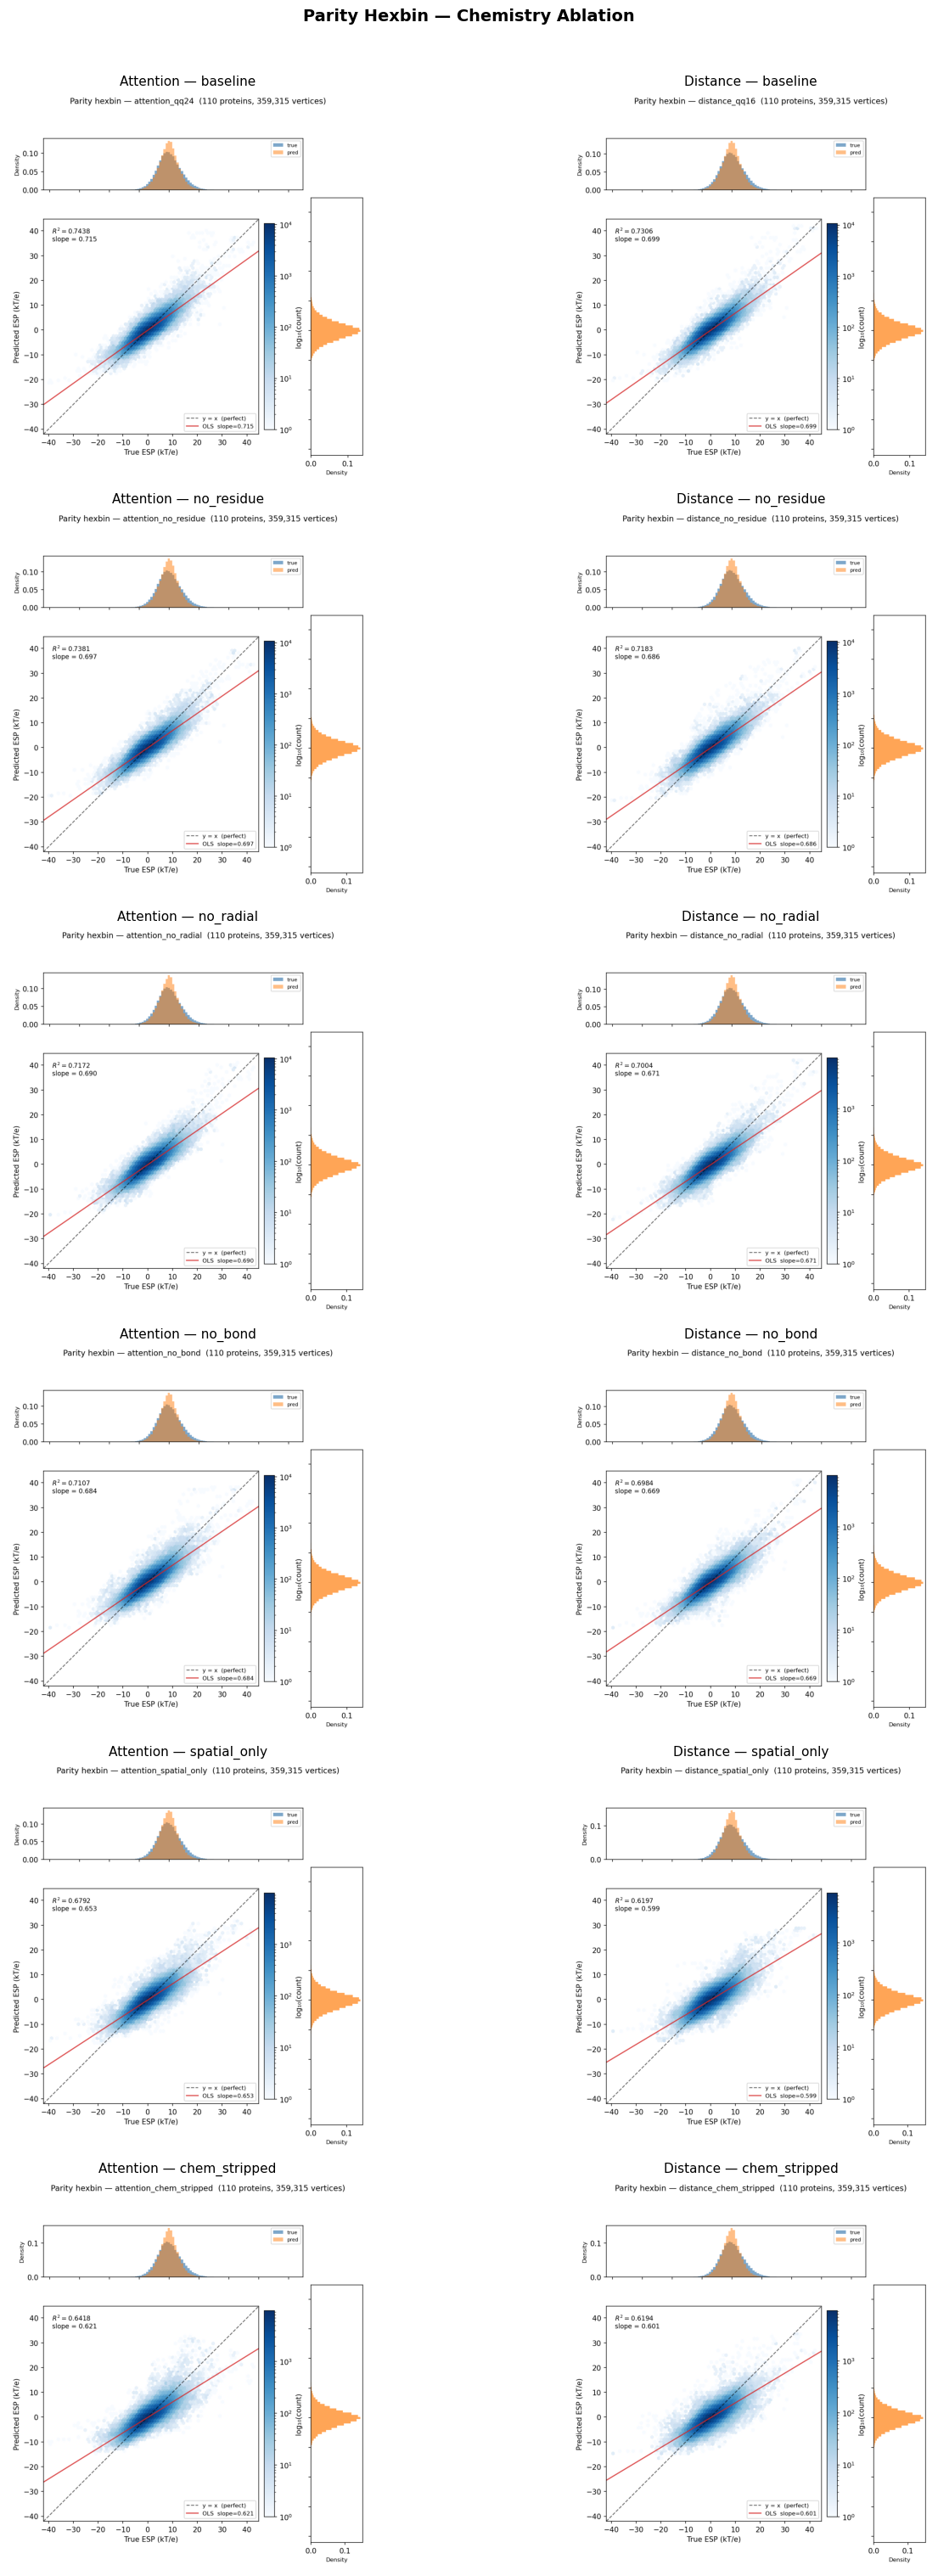

In [3]:
show_png_grid(RUNS, "parity_hexbin.png", "Parity Hexbin — Chemistry Ablation", ncols=2)

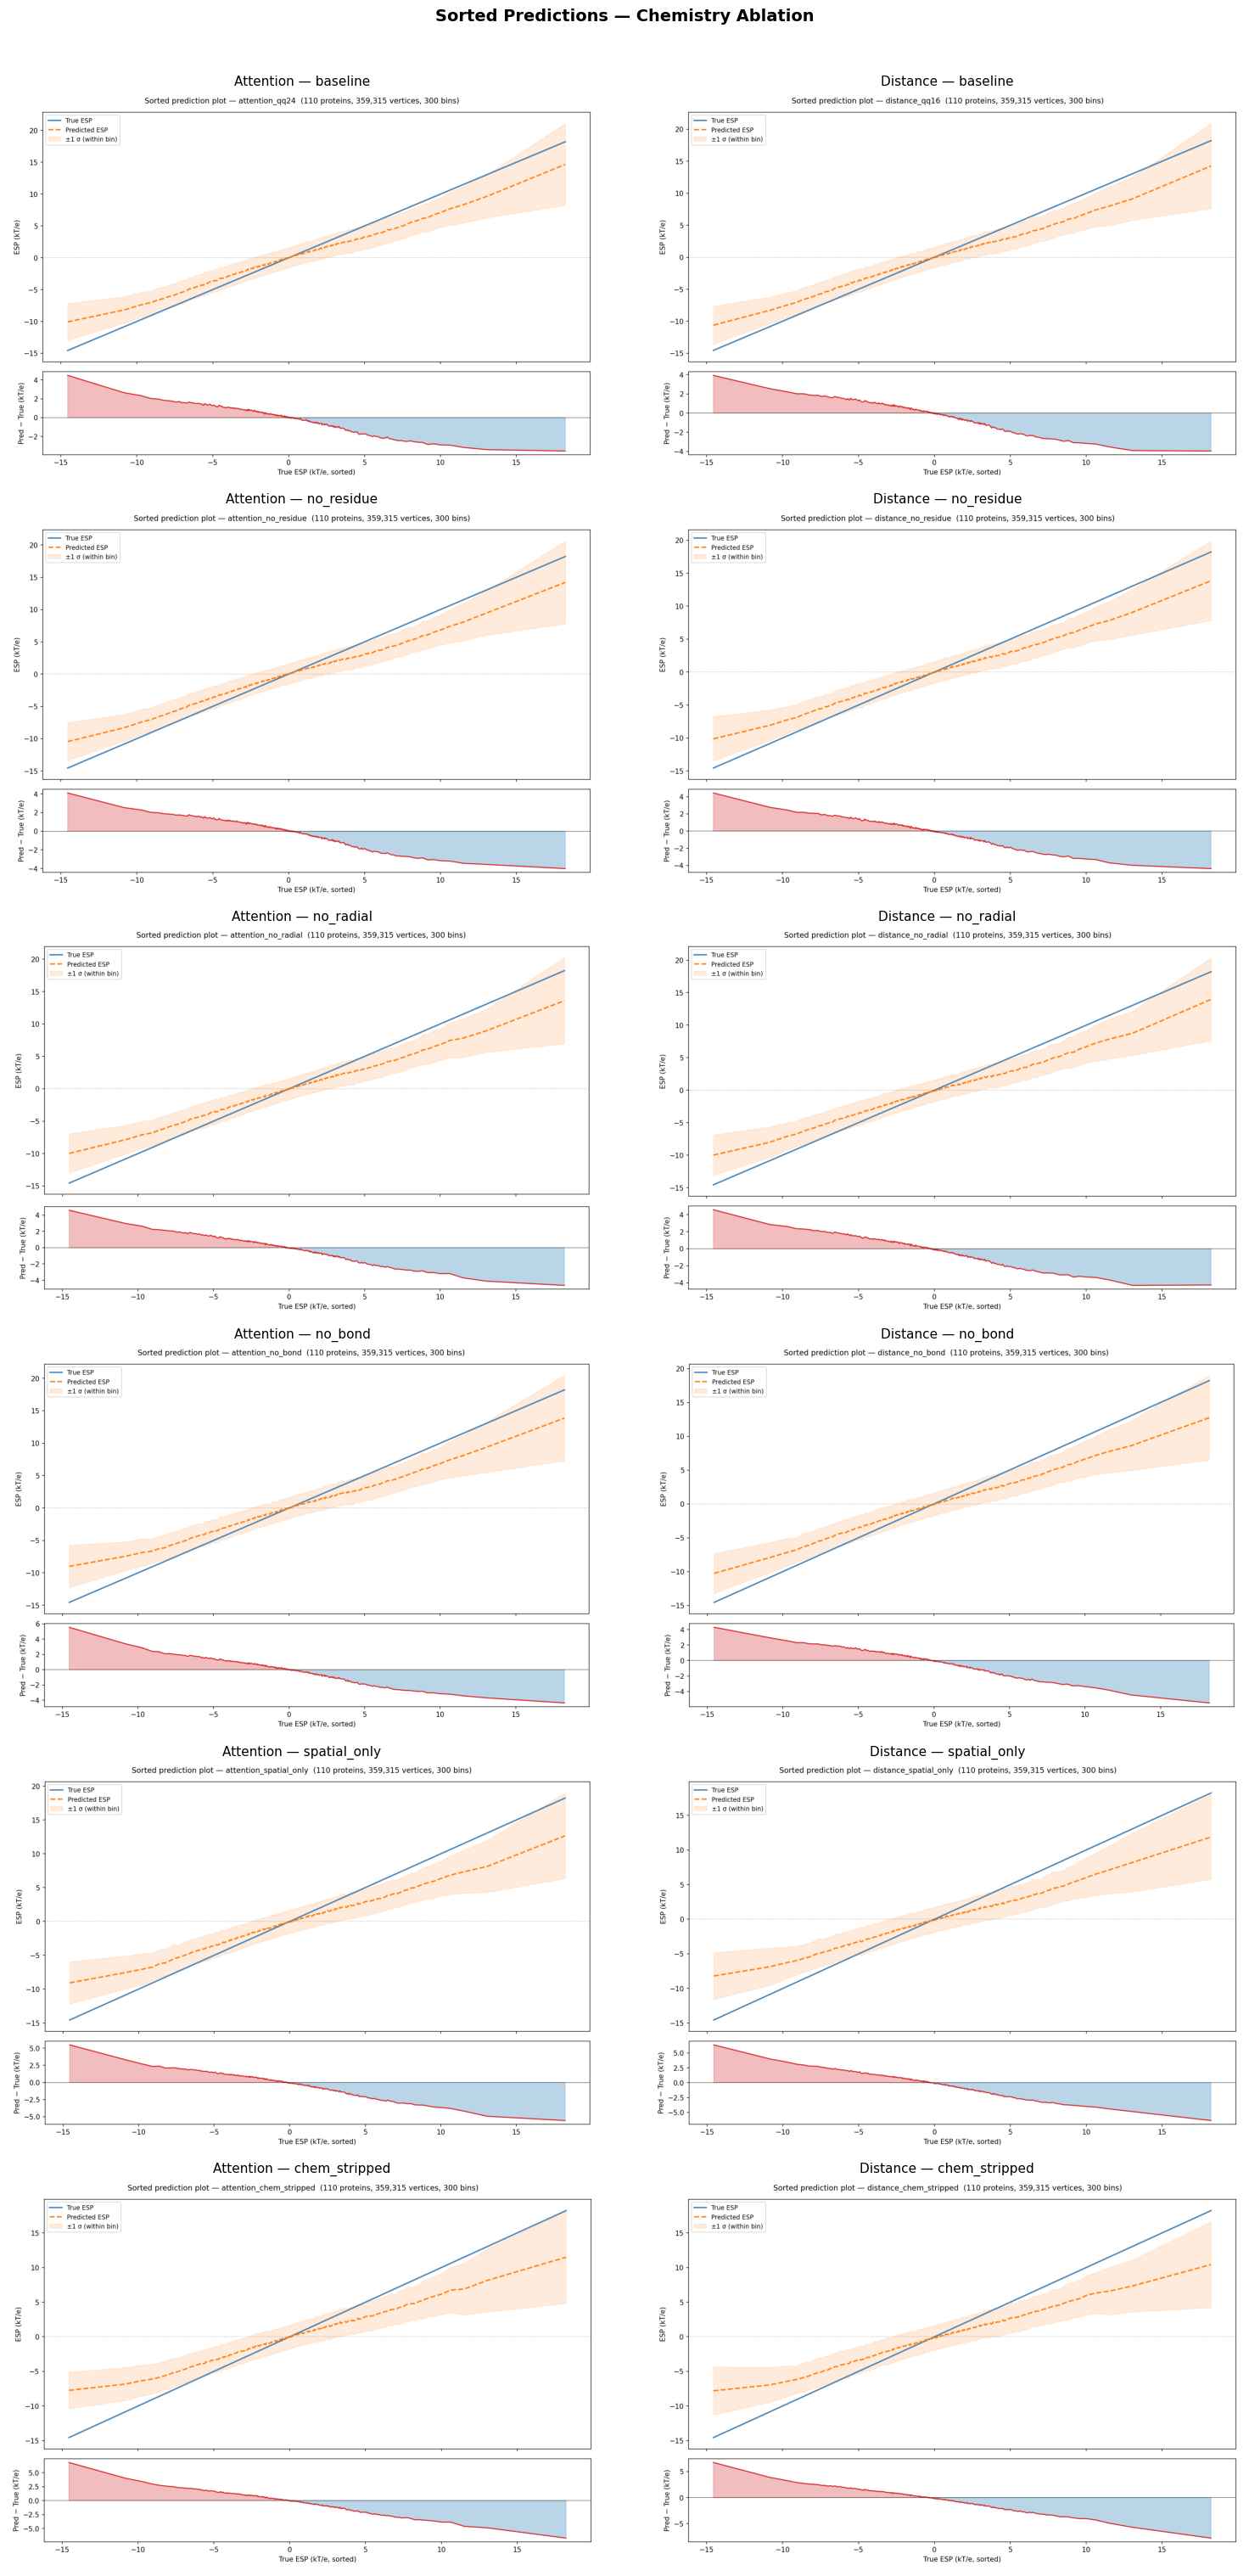

In [4]:
show_png_grid(RUNS, "sorted_predictions.png", "Sorted Predictions — Chemistry Ablation", ncols=2)

## 3. Per-Bin Comparison vs Baseline

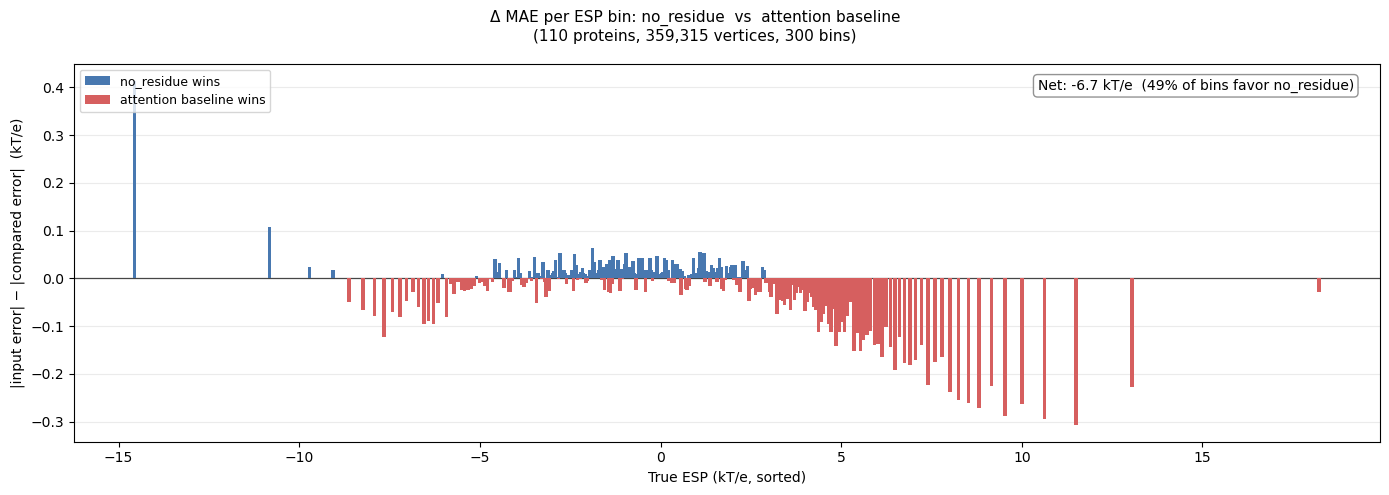

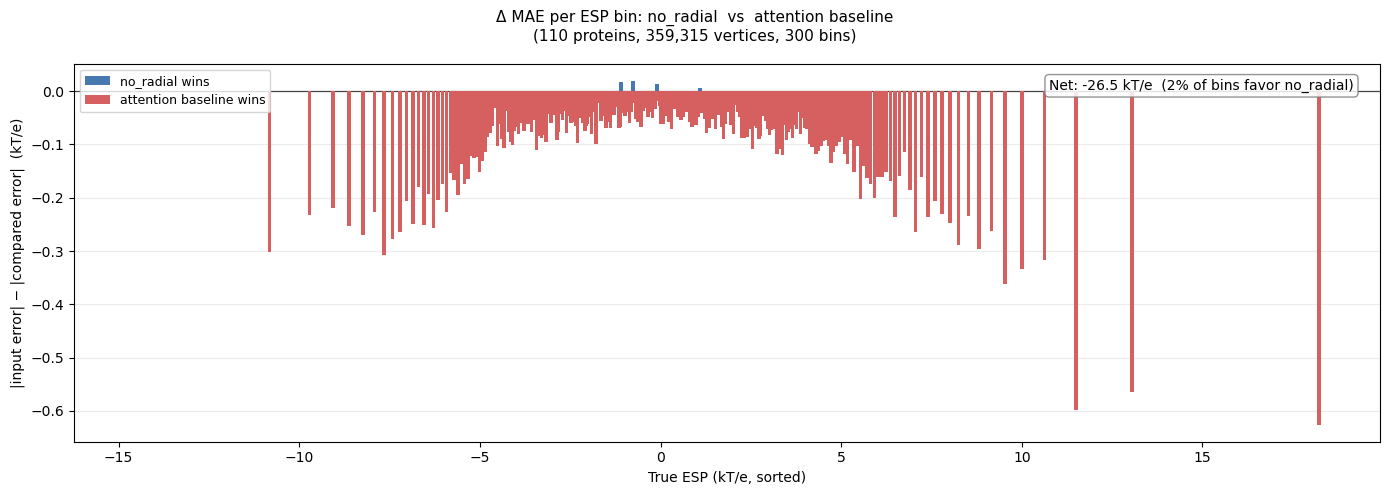

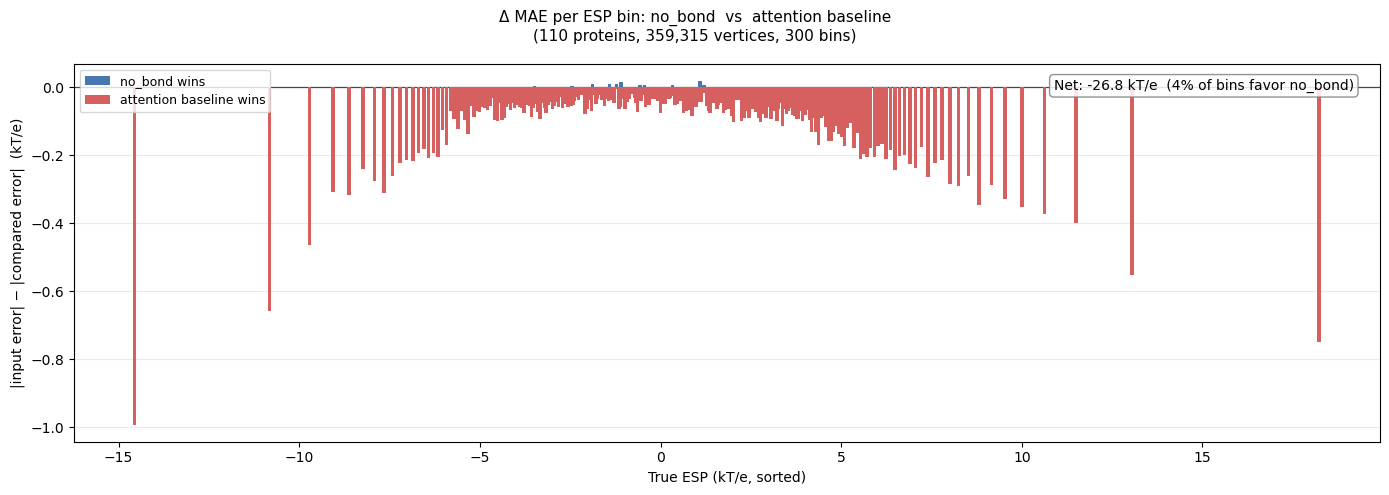

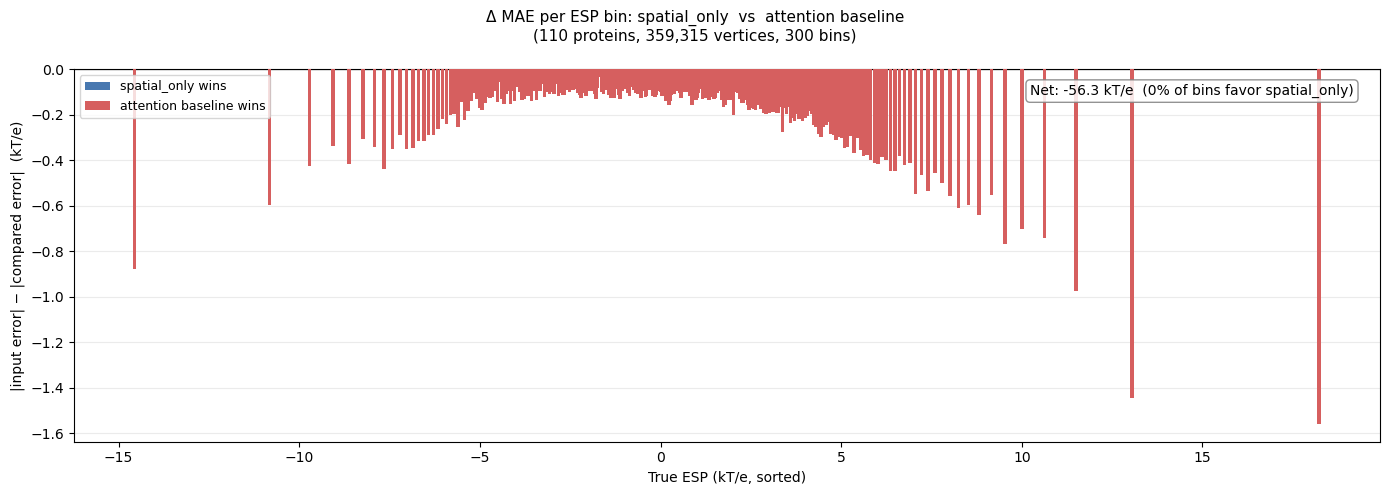

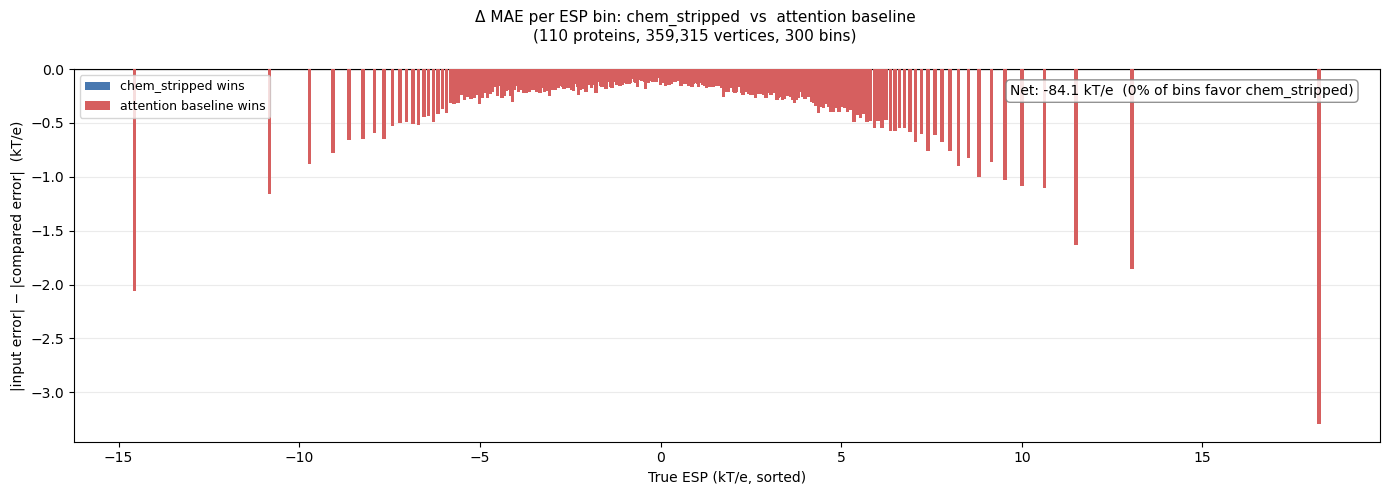

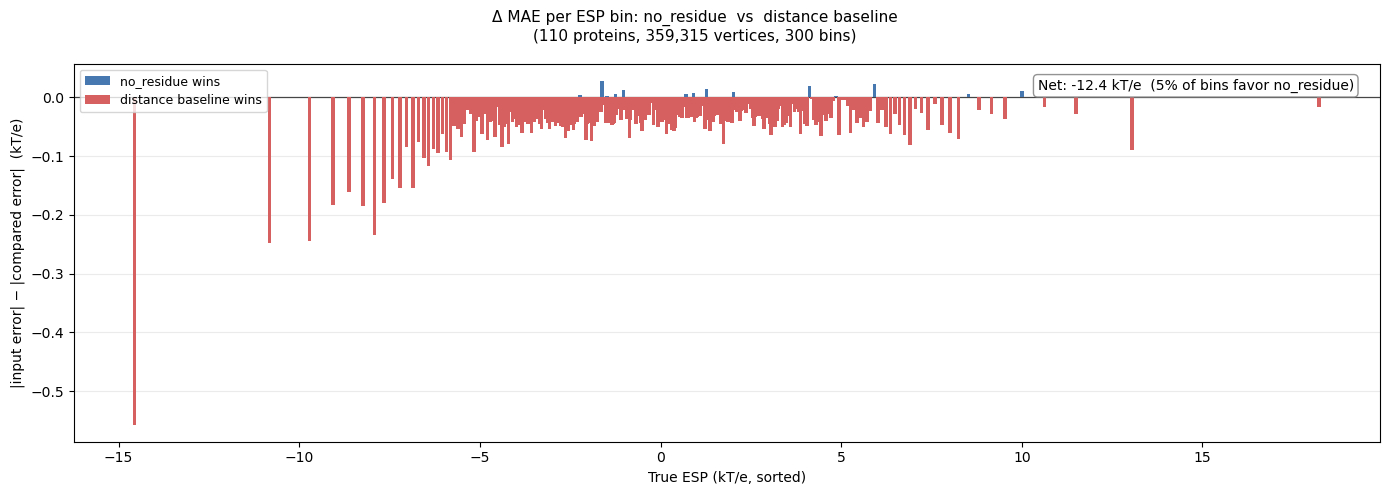

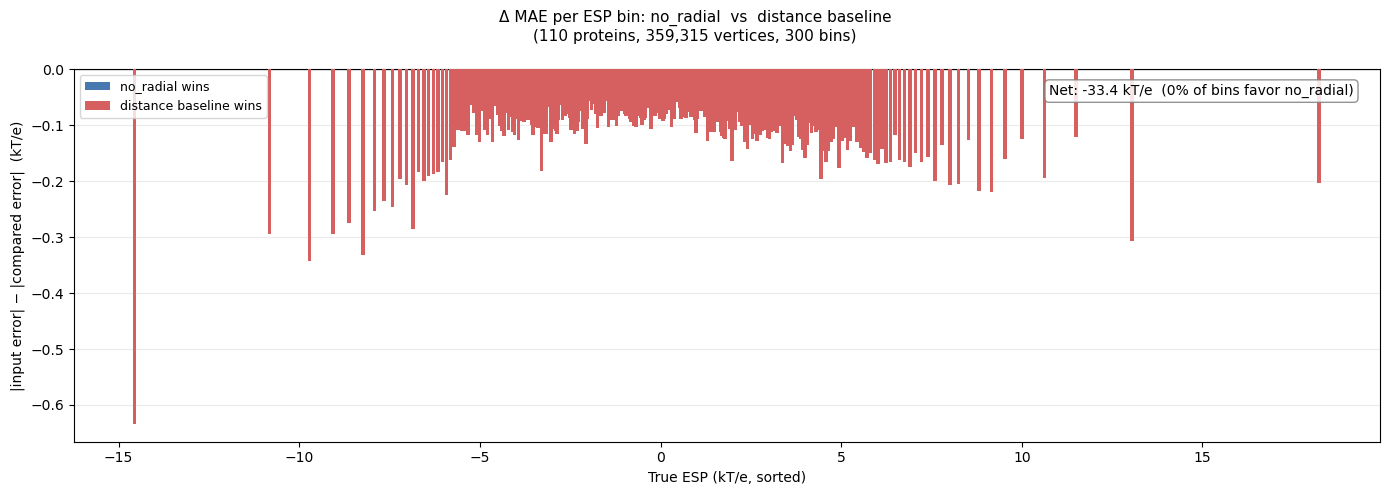

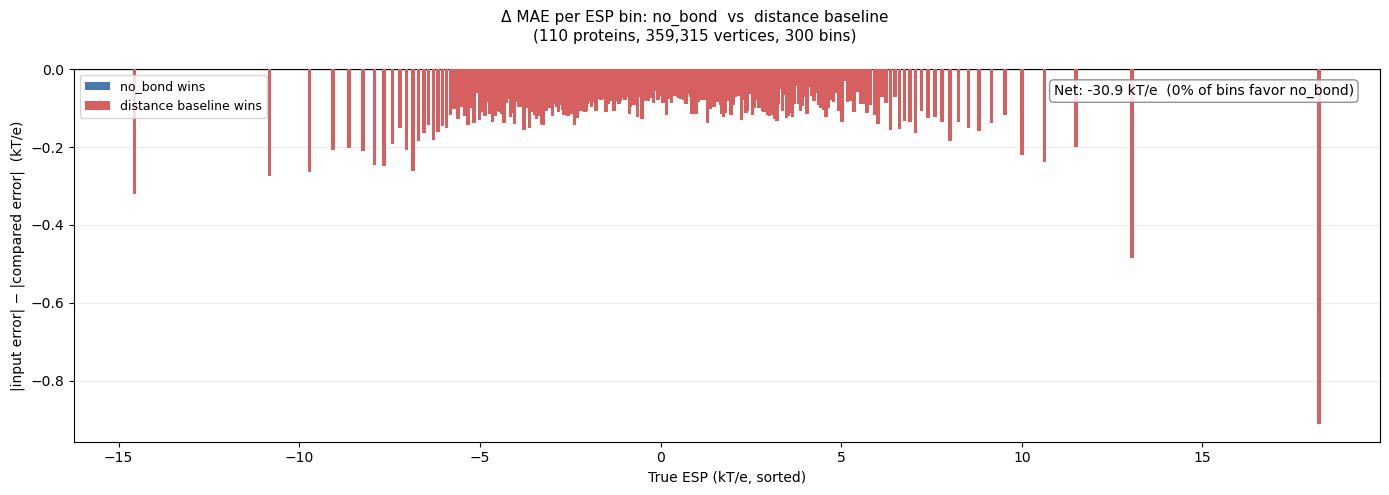

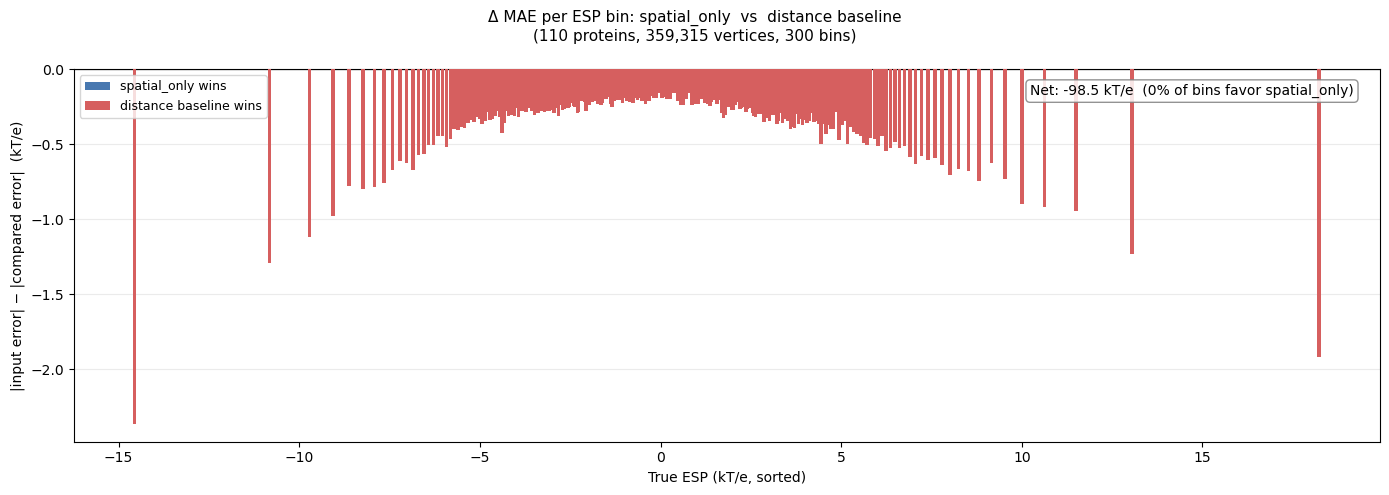

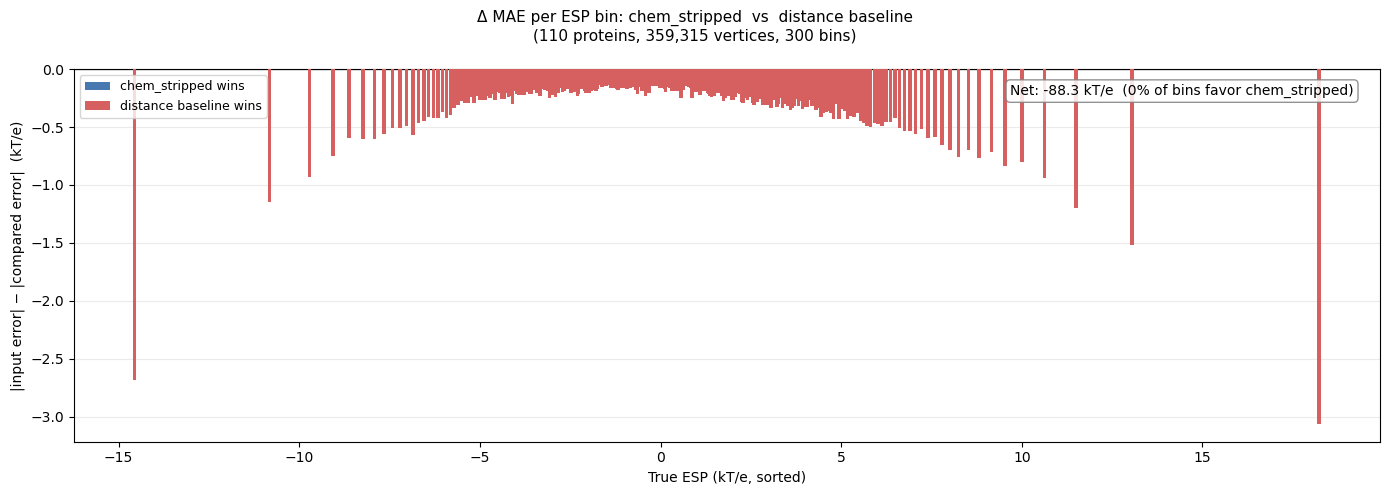

In [5]:
from src.analysis.model_plots import plot_delta_predictions

for m in ["attention", "distance"]:
    base_dir = CKPT_ROOT / "phase_d" / BASELINE_CKPT[m]
    for run in RUNS:
        if run["model_type"] != m or run["config"] == "baseline":
            continue
        plot_delta_predictions(
            input_ckpt_dir=base_dir, compared_ckpt_dir=run["ckpt_dir"],
            input_label=f"{m} baseline", compared_label=run["config"],
        )

## 4. Training Curves

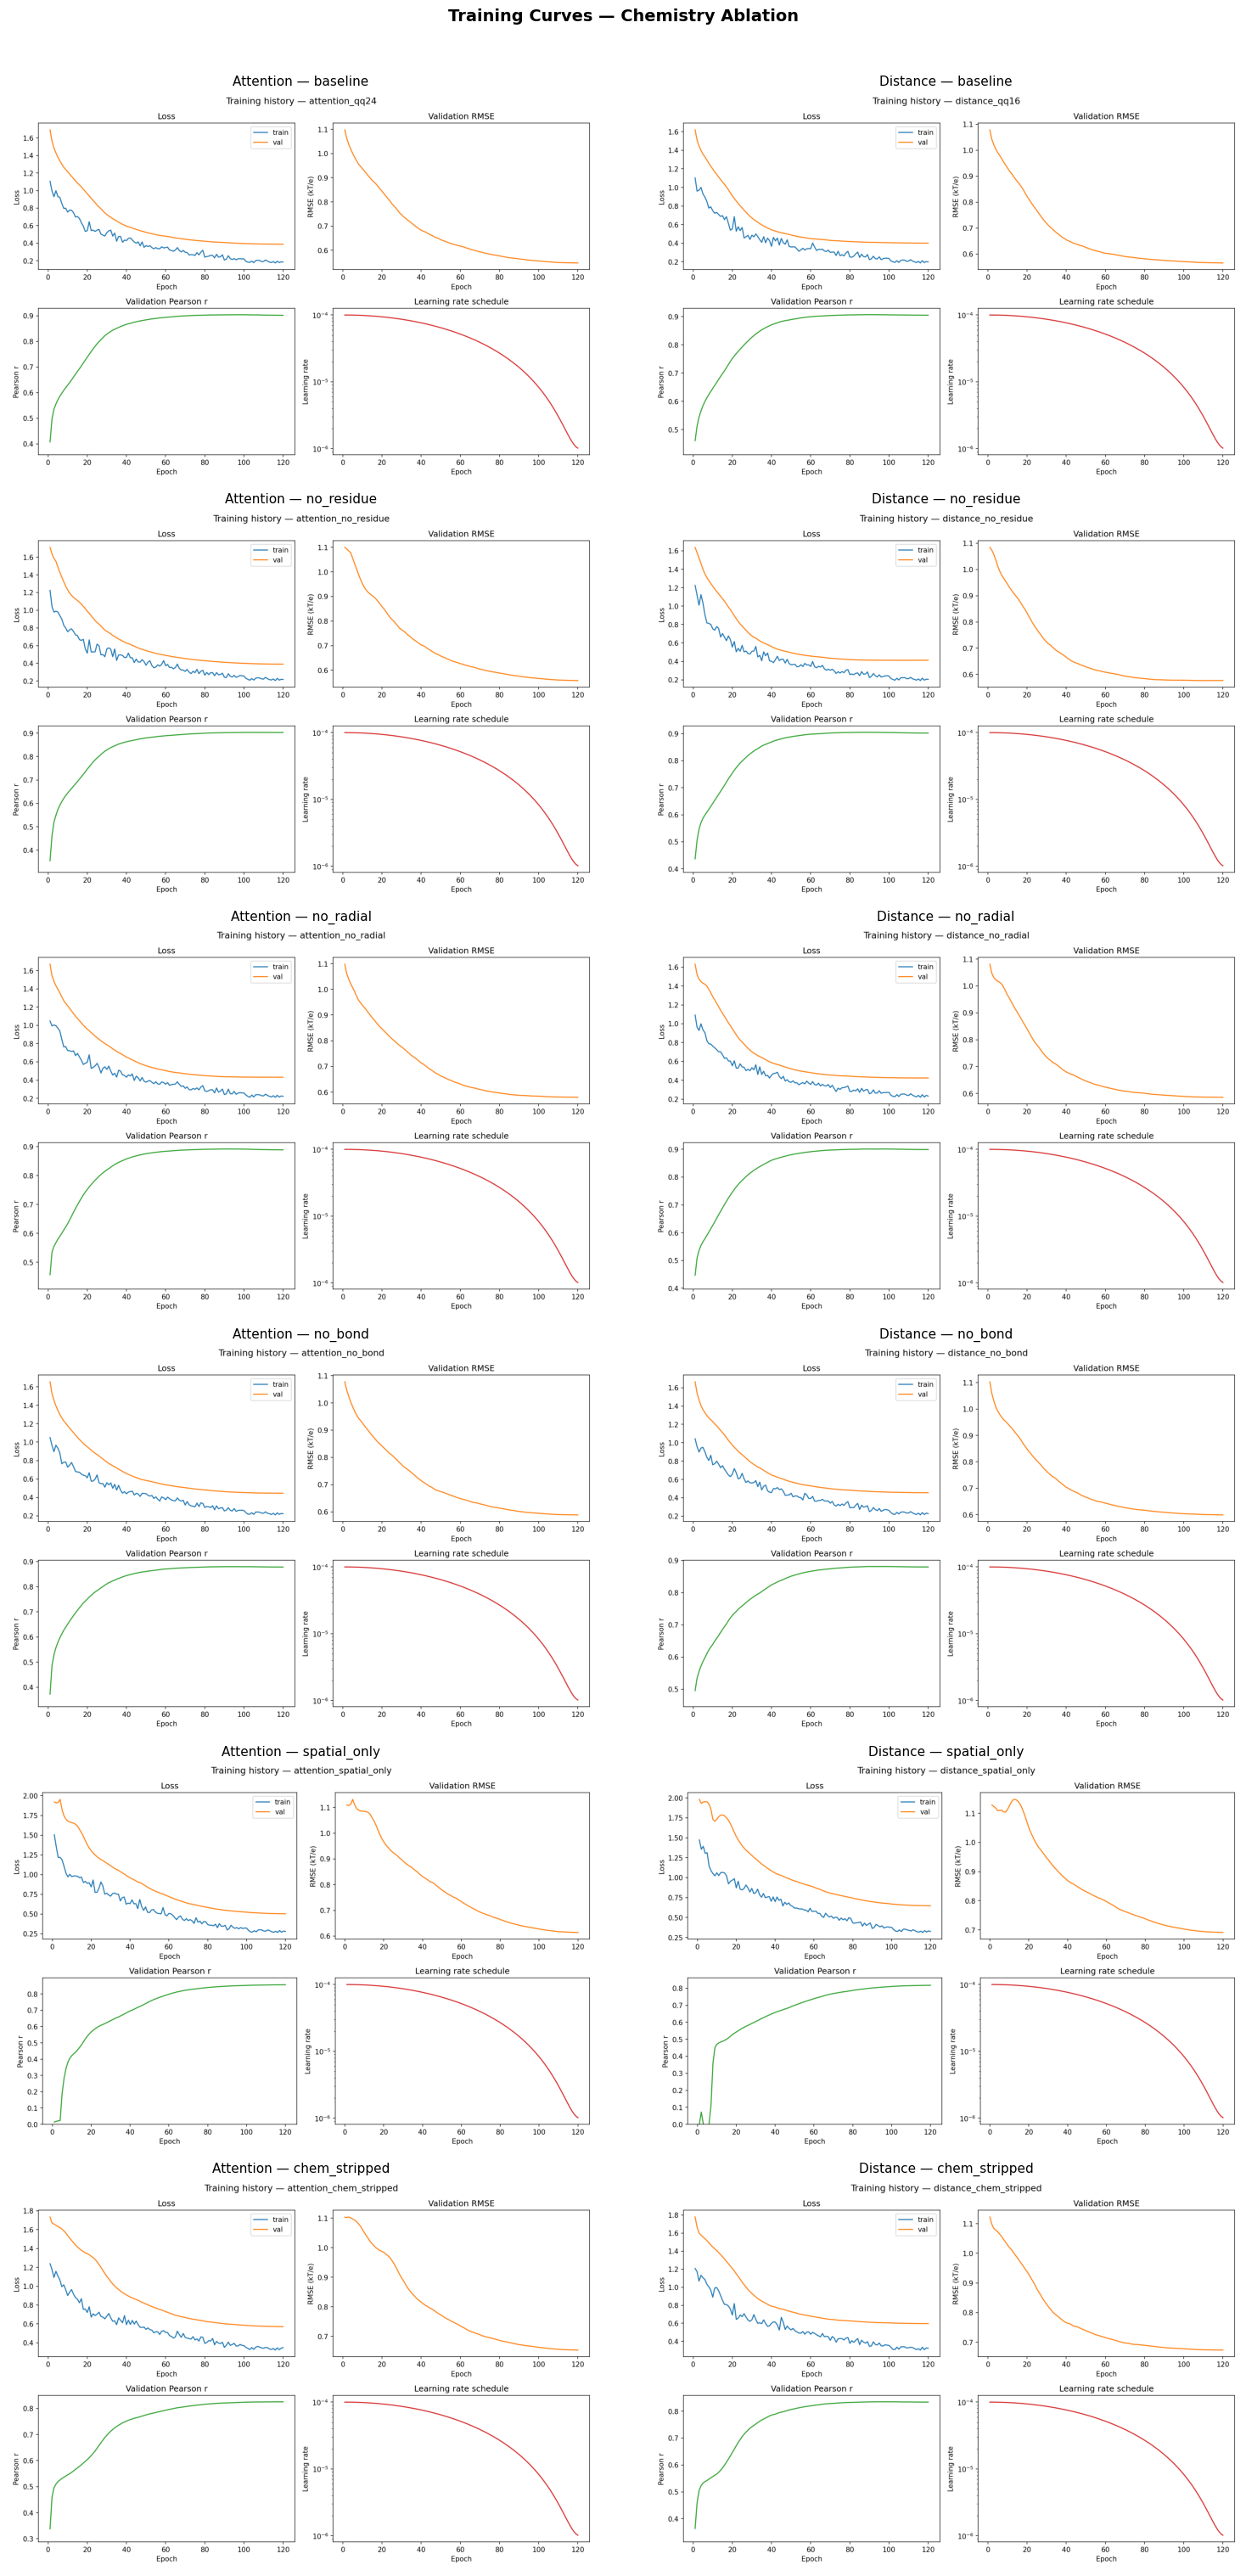

In [6]:
show_png_grid(RUNS, "training_curves.png", "Training Curves — Chemistry Ablation", ncols=2)

## 5. Validation Metrics Comparison (selection basis)

,Run,Model,Config,Pearson r,RMSE,Val loss,Train loss,Train/val gap,Best epoch
2,Attention — no_residue,Attention,no_residue,0.9029,0.5577,0.3904,0.2176,-0.1729,120
0,Attention — baseline,Attention,baseline,0.9016,0.5473,0.3879,0.1856,-0.2024,120
4,Attention — no_radial,Attention,no_radial,0.8891,0.5796,0.4311,0.2227,-0.2085,120
6,Attention — no_bond,Attention,no_bond,0.8786,0.5886,0.4455,0.2229,-0.2226,120
8,Attention — spatial_only,Attention,spatial_only,0.8565,0.6138,0.5027,0.2783,-0.2244,120
10,Attention — chem_stripped,Attention,chem_stripped,0.8255,0.6535,0.5711,0.3492,-0.2219,120
1,Distance — baseline,Distance,baseline,0.9046,0.5657,0.4001,0.1984,-0.2017,120
3,Distance — no_residue,Distance,no_residue,0.9032,0.5767,0.4113,0.2243,-0.1871,108
5,Distance — no_radial,Distance,no_radial,0.8993,0.5857,0.4255,0.2333,-0.1922,120
7,Distance — no_bond,Distance,no_bond,0.8797,0.5990,0.4551,0.2272,-0.2279,120


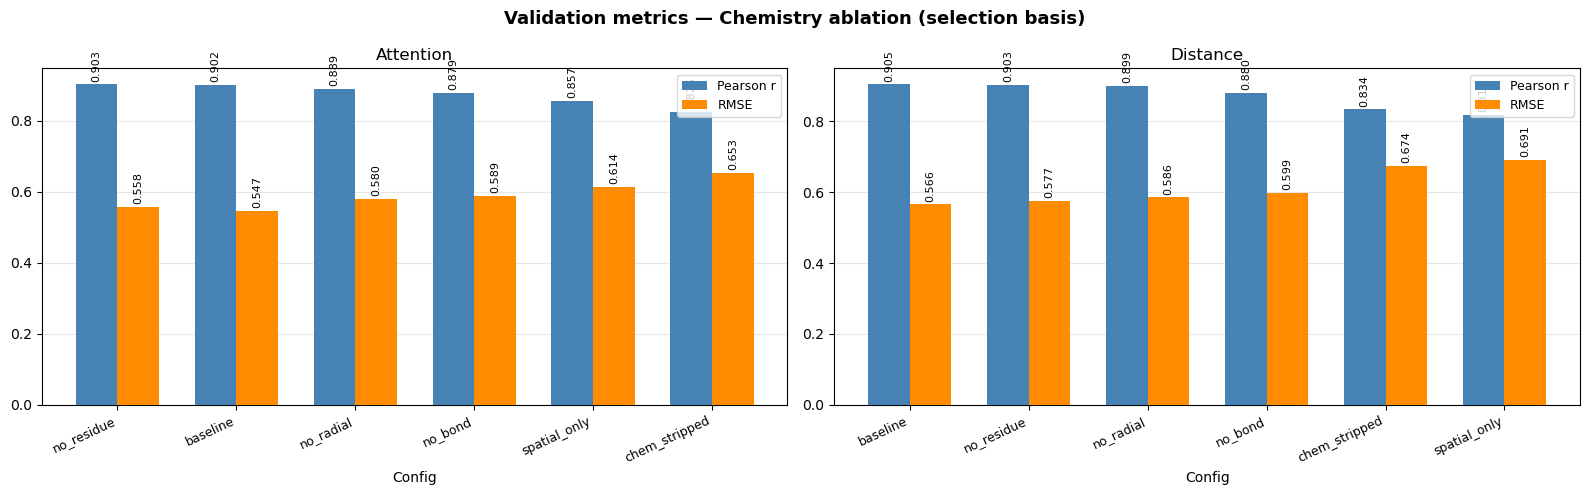

In [7]:
rows = []
for run in RUNS:
    csv_path = run["ckpt_dir"] / "metrics.csv"
    if not csv_path.exists():
        continue
    hist = pd.read_csv(csv_path)
    if hist.empty:
        continue
    best = hist.loc[hist["val_loss"].idxmin()]
    rows.append({
        "Run":           run["label"],
        "Model":         run["model_type"].capitalize(),
        "Config":        run["config"],
        "Pearson r":     best["val_pearson_r"],
        "RMSE":          best["val_rmse"],
        "Val loss":      best["val_loss"],
        "Train loss":    best["train_loss"],
        "Train/val gap": best["train_loss"] - best["val_loss"],
        "Best epoch":    int(best["epoch"]),
    })

val_df = pd.DataFrame(rows).sort_values(["Model", "Pearson r"], ascending=[True, False])
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
display(val_df)
plot_metric_bars(val_df, "Validation metrics — Chemistry ablation (selection basis)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange")])

## 6. Test Metrics (reference only — not used for selection)

,Run,Model,Config,Pearson r,RMSE,MAE,Train time (s),N proteins
0,Attention — baseline,Attention,baseline,0.9078,2.1356,1.6324,7924.9000,110
2,Attention — no_residue,Attention,no_residue,0.9042,2.1612,1.6548,12562.4000,110
4,Attention — no_radial,Attention,no_radial,0.8939,2.2438,1.7207,9615.0000,110
6,Attention — no_bond,Attention,no_bond,0.8822,2.2701,1.7217,12304.6000,110
8,Attention — spatial_only,Attention,spatial_only,0.8564,2.3887,1.8199,11834.6000,110
10,Attention — chem_stripped,Attention,chem_stripped,0.8335,2.5271,1.9126,8734.7000,110
1,Distance — baseline,Distance,baseline,0.9108,2.1898,1.6740,8715.9000,110
3,Distance — no_residue,Distance,no_residue,0.9029,2.2388,1.7152,11668.2000,110
5,Distance — no_radial,Distance,no_radial,0.9018,2.3093,1.7853,8473.3000,110
7,Distance — no_bond,Distance,no_bond,0.8822,2.3175,1.7769,10777.5000,110


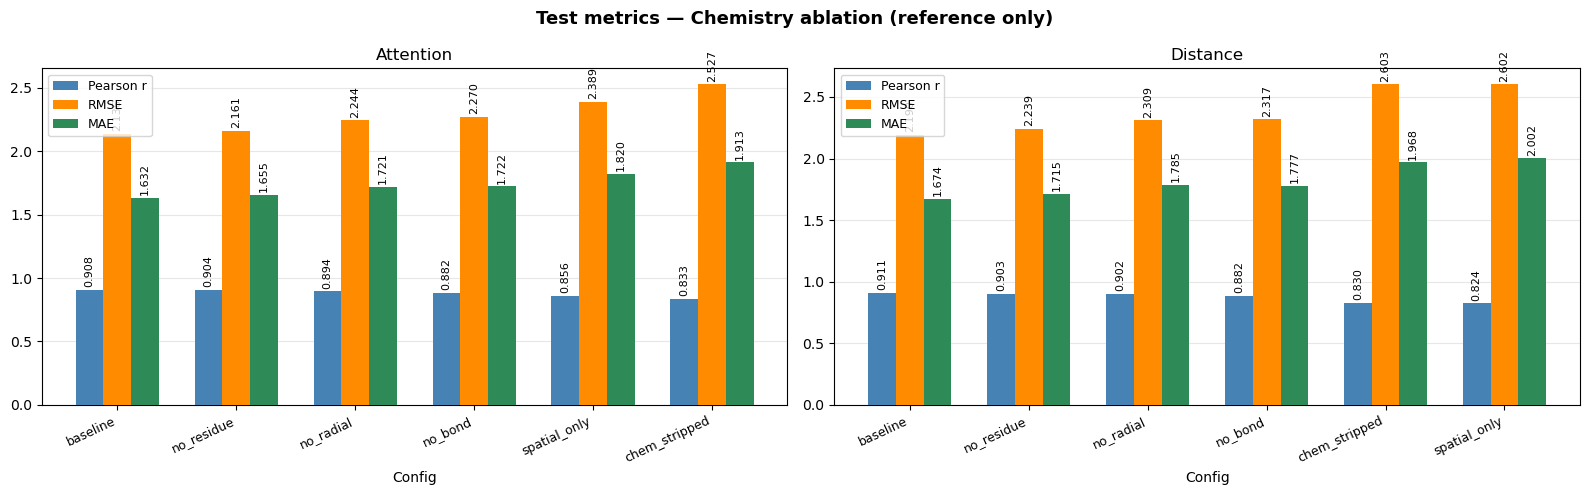

In [8]:
rows_test = []
for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_test.append({
        "Run":            run["label"],
        "Model":          run["model_type"].capitalize(),
        "Config":         run["config"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

test_df = pd.DataFrame(rows_test).sort_values(["Model", "Pearson r"], ascending=[True, False])
display(test_df)
plot_metric_bars(test_df, "Test metrics — Chemistry ablation (reference only)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")])

## 7. Per-Protein Ranking

Per-protein Pearson r (from `test_metrics.json`) across all 12 runs — which
proteins are universally easy or hard, and which are chemistry-sensitive
(high rank variance across the ablation ladder)?

In [9]:
pp_data: dict[str, dict[str, float]] = {}

for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]
pivot.columns = [
    label.replace("Attention — ", "Attn/").replace("Distance — ", "Dist/")
    for label in pivot.columns
]

pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 110 proteins across 12 runs.


In [10]:
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print("Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print("\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print("\nMost chemistry-sensitive proteins (highest rank std):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,Attn/baseline,Dist/baseline,Attn/no_residue,Dist/no_residue,Attn/no_radial,Dist/no_radial,Attn/no_bond,Dist/no_bond,Attn/spatial_only,Dist/spatial_only,Attn/chem_stripped,Dist/chem_stripped
Q8WXC6,0.9559,0.0113,2.5000,3.1200,12,3,2,3,1,1,1,1,3,1,1,1
Q7MYW8,0.9428,0.0153,5.7500,2.9000,14,5,5,6,3,4,8,4,4,6,5,5
Q9GKK3-3,0.9402,0.0148,7.2500,2.7300,7,6,8,10,9,7,5,6,14,5,4,6
A1SHW4,0.9419,0.0143,7.5000,5.1800,5,10,4,13,12,3,6,19,2,3,9,4
Q8N100,0.9432,0.0103,7.5800,6.9600,21,12,6,21,7,5,2,5,1,7,2,2



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,Attn/baseline,Dist/baseline,Attn/no_residue,Dist/no_residue,Attn/no_radial,Dist/no_radial,Attn/no_bond,Dist/no_bond,Attn/spatial_only,Dist/spatial_only,Attn/chem_stripped,Dist/chem_stripped
A2T2X4,0.8029,0.0330,102.0000,4.2900,105,105,104,106,105,101,102,104,104,93,101,94
B5QU79,0.7558,0.0594,103.3300,7.7700,109,109,108,110,106,108,106,105,86,91,97,105
A4W488,0.7263,0.1346,104.0000,6.2400,108,110,107,101,100,103,90,110,108,109,96,106
Q5P107,0.6733,0.1629,106.4200,3.6000,100,102,103,108,108,110,109,109,102,107,110,109
P0A6Y5,0.7272,0.0532,106.6700,3.3100,107,106,110,109,107,109,108,108,107,100,109,100



Most chemistry-sensitive proteins (highest rank std):


,Mean r,Std r,Mean rank,Rank std,Attn/baseline,Dist/baseline,Attn/no_residue,Dist/no_residue,Attn/no_radial,Dist/no_radial,Attn/no_bond,Dist/no_bond,Attn/spatial_only,Dist/spatial_only,Attn/chem_stripped,Dist/chem_stripped
B7NEU6,0.9025,0.0572,34.9200,30.8600,8,13,19,15,24,25,68,30,94,90,23,10
Q9H5Q4,0.8864,0.0550,51.0000,30.4900,27,41,23,42,33,40,100,85,18,25,85,93
O23522,0.8974,0.0497,42.8300,28.6000,28,31,12,18,14,23,67,95,22,59,66,79
Q58784,0.8991,0.0277,43.0000,27.5600,40,103,28,90,40,22,31,54,47,23,15,23
P47486,0.8498,0.0796,75.4200,26.9100,37,35,46,83,90,92,89,88,42,97,103,103


## 8. Decision

*Fill in once reviewed under the new plot standard. Template:*

| Model | Rung where performance first drops meaningfully | Val Pearson r at that rung | Val RMSE | Notes |
|---|---|---|---|---|
| Attention | ? | ? | ? | ? |
| Distance | ? | ? | ? | ? |

**Reasoning:** *which chemistry-carrying inputs are load-bearing vs
redundant, and whether the drop is gradual (each ingredient contributes a
little) or a cliff at one specific rung (one ingredient is doing most of the
work).*